<a href="https://colab.research.google.com/github/sweetysneha005/Data_Mining-Project/blob/main/dataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Definition

The objective of this project is to predict whether a patient has diabetes
based on medical attributes such as glucose level, BMI, age, blood pressure,
and insulin level.

Type of Problem: Classification

Algorithm Used: Decision Tree Classifier

Target Variable: Outcome
0 → No Diabetes
1 → Diabetes

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Data Preprocessing


In [ ]:
df.isnull().sum()


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df['smoking_history'] = df['smoking_history'].astype('category').cat.codes
df['smoking_history'].head()

,smoking_history
0,4
1,0
2,4
3,1
4,1


In [ ]:
data = df.copy()

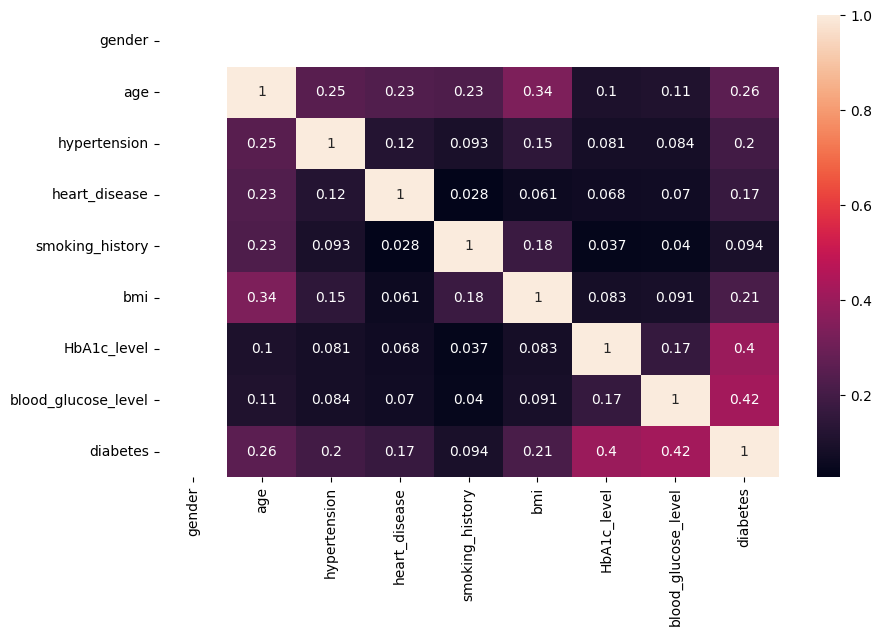

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print(X.head())
print(y.head())

   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0     NaN  80.0             0              1                4  25.19   
1     NaN  54.0             0              0                0  27.32   
2     NaN  28.0             0              0                4  27.32   
3     NaN  36.0             0              0                1  23.45   
4     NaN  76.0             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  
0          6.6                  140  
1          6.6                   80  
2          5.7                  158  
3          5.0                  155  
4          4.8                  155  
0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64


Replaced NaN values


In [ ]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())


In [ ]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
print(X.isnull().sum())

gender                 100000
age                         0
hypertension                0
heart_disease               0
smoking_history             0
bmi                         0
HbA1c_level                 0
blood_glucose_level         0
dtype: int64


string into numeric

In [ ]:
df['gender'] = df['gender'].map({
    'Male': 1,
    'Female': 0,
    'Other': 2
})
df['smoking_history'] = df['smoking_history'].astype('category').cat.codes
df.dtypes

,0
gender,float64
age,float64
hypertension,int64
heart_disease,int64
smoking_history,int8
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


Feature Selection

In [ ]:
import pandas as pd
import numpy as np # Import numpy for NaN handling
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

if X.isnull().sum().sum() > 0:
    X = X.fillna(0)
selector = SelectKBest(score_func=chi2, k=6)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)

X = pd.DataFrame(X_new, columns=selected_features)

Selected Features: Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level'],
      dtype='object')


Spliting data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 6)
(20000, 6)


choose classification Algorithm (Decision tree)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

Train The Model

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Test the classifier

In [ ]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Evaluate the model.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97215


Addition metrics


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18292     0]
 [  557  1151]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18292
           1       1.00      0.67      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



improve the model

In [ ]:
model2 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=7,
    min_samples_split=4,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score

print("Improved Accuracy:", accuracy_score(y_test, y_pred2))

Improved Accuracy: 0.97215


Decision tree Visualization

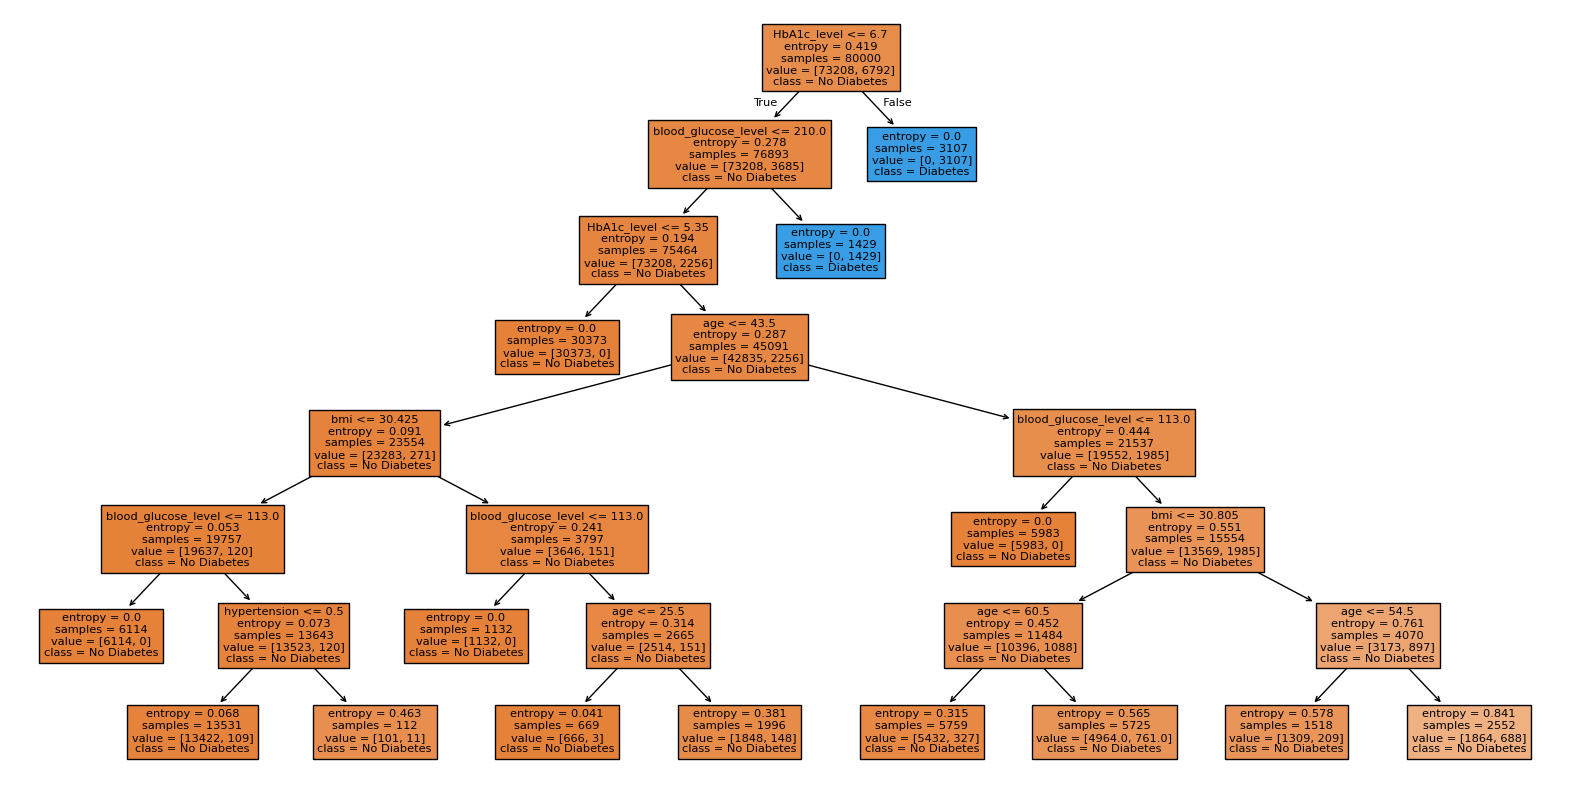

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model2,
    feature_names=X.columns,
    class_names=['No Diabetes','Diabetes'],
    filled=True
)

plt.show()

Random Forest training (2nd classifier)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       random_state=42)

test random forest

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[0 0 0 0 0 1 0 0 0 0]


Evaluate

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9094
Confusion Matrix:
[[16641  1651]
 [  161  1547]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18292
           1       0.48      0.91      0.63      1708

    accuracy                           0.91     20000
   macro avg       0.74      0.91      0.79     20000
weighted avg       0.95      0.91      0.92     20000



The file 'diabetes.csv' was not found. Please upload it now:


Saving diabetes.csv to diabetes.csv


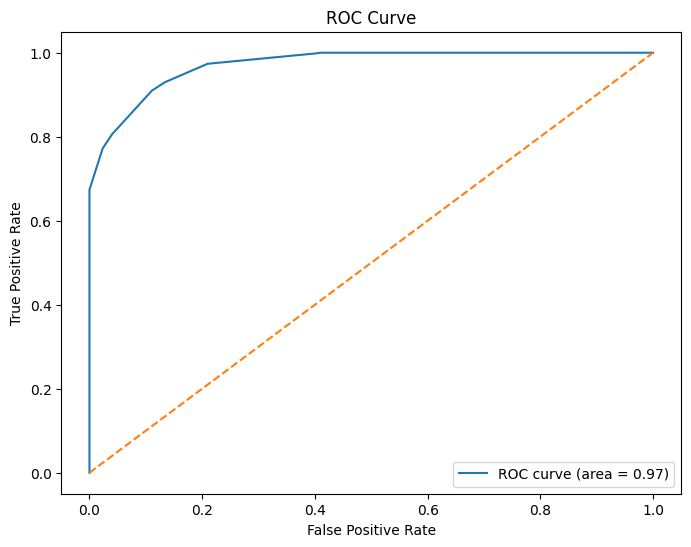

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from google.colab import files # Import files for upload
import os # Import os for file path checking

# --- Reconstruct df, X, y, X_train, y_train, X_test, y_test ---
# Data Loading and Preprocessing (from previous cells: RVuKygdIoHJy, 0gPNagk5rEdJ)

# Check if 'diabetes.csv' exists, if not, prompt for upload
file_path = "diabetes.csv"
if not os.path.exists(file_path):
    print(f"The file '{file_path}' was not found. Please upload it now:")
    files.upload() # This will open a file picker for the user

df = pd.read_csv(file_path)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Other': 2})
df['smoking_history'] = df['smoking_history'].astype('category').cat.codes

# Feature Selection (adapted from GaMz6p6kqOGJ)
X_data_for_fs = df.drop("diabetes", axis=1)
y_data_for_fs = df["diabetes"]

X_data_for_fs = X_data_for_fs.replace([np.inf, -np.inf], np.nan)
X_data_for_fs = X_data_for_fs.fillna(X_data_for_fs.median(numeric_only=True))
if X_data_for_fs.isnull().sum().sum() > 0: # Ensure all NaNs are handled if any remain
    X_data_for_fs = X_data_for_fs.fillna(0)

selector = SelectKBest(score_func=chi2, k=6)
X_selected = selector.fit_transform(X_data_for_fs, y_data_for_fs)
selected_feature_names = X_data_for_fs.columns[selector.get_support()]

X = pd.DataFrame(X_selected, columns=selected_feature_names)
y = y_data_for_fs # The target variable remains the same

# Split Data (from JiOvtLpGrhMO)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# --- Decision Tree Model and ROC Curve Plotting (original content + fix for model2) ---
# Re-define and fit model2 (since it was not defined in the current execution context in the previous turn)
model2 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=7,
    min_samples_split=4,
    random_state=42
)
model2.fit(X_train, y_train)

# Predict probabilities (important for ROC)
y_prob = model2.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()